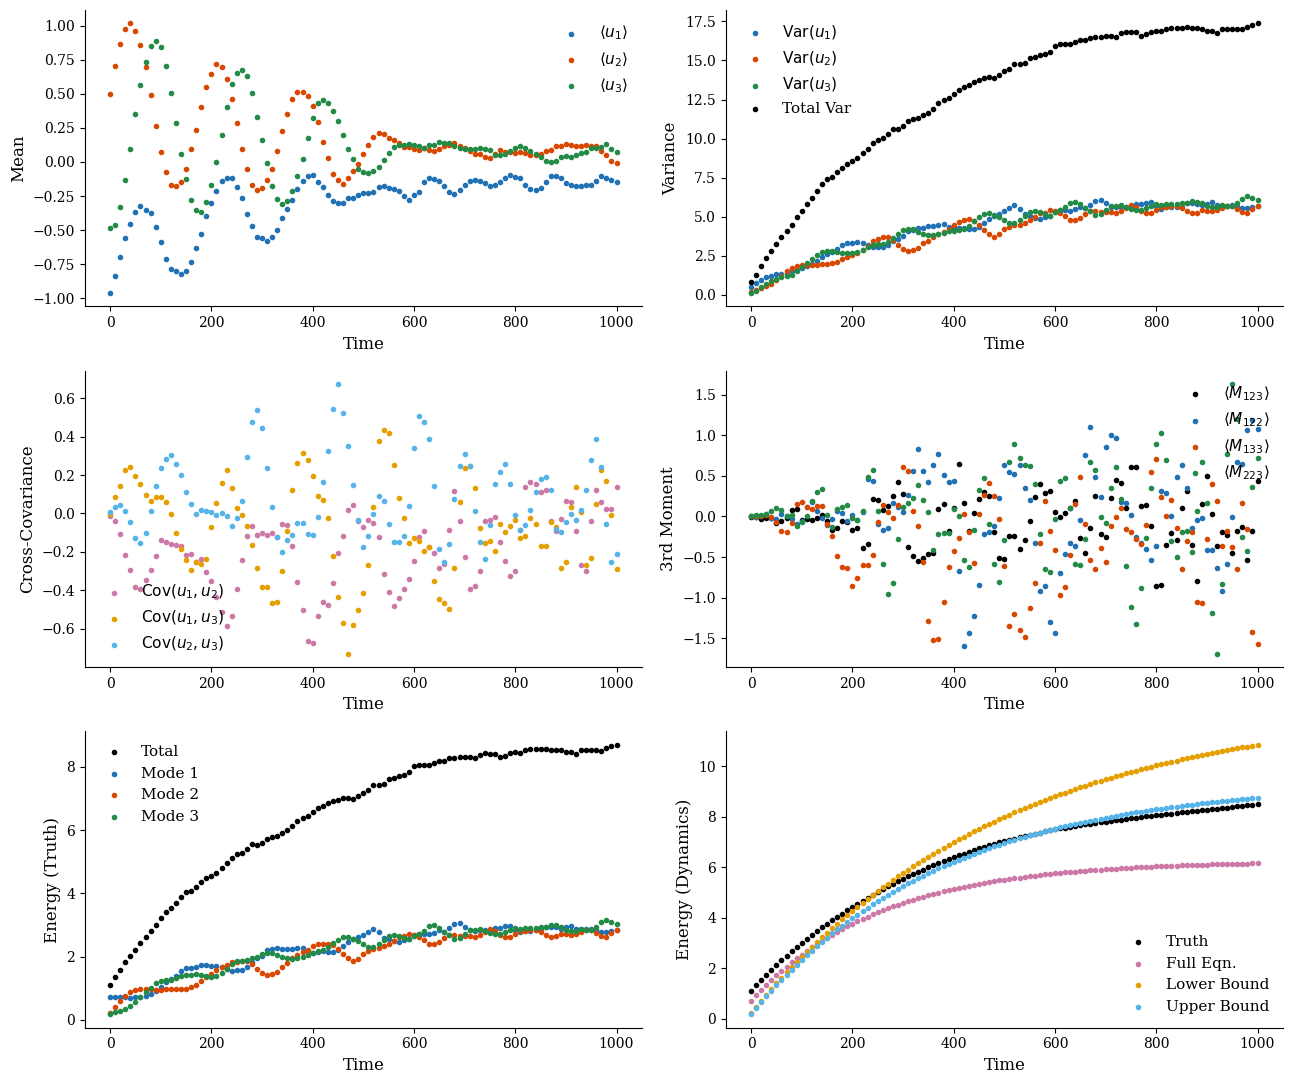

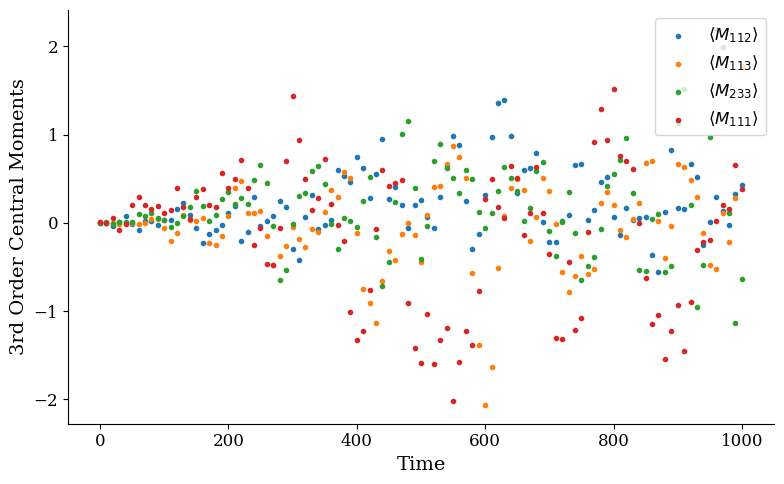

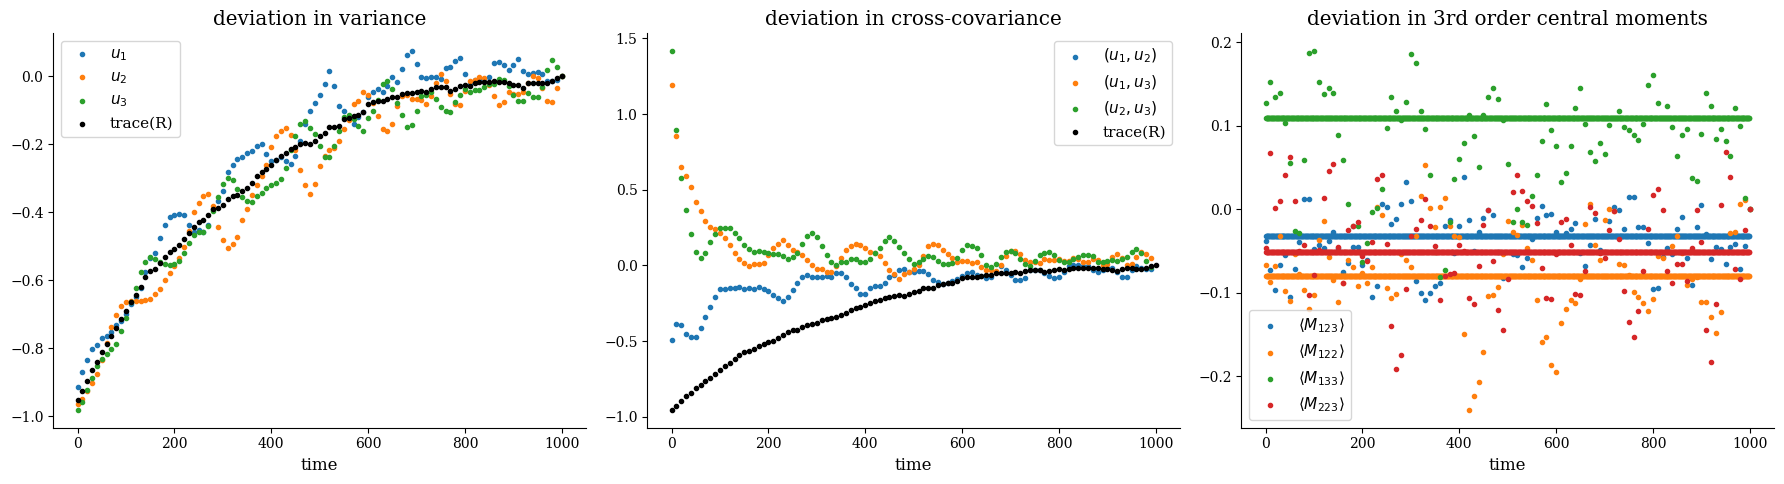

In [1]:
from MC_triad import *
import os
from pathlib import Path
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..",'..')))
from utils.plotting import plot_stats, plot_third_order_moments, plot_deviation_subplots
'''First, check the results of equation
1. why we need to use the deviation in variance and cross-covariance to plot the deviation in 3rd order central moments?
2. why we need to use the deviation in 3rd order central moments to plot the deviation in energy?
3. why we need to use the deviation in energy to plot the deviation in 3rd order central moments?
'''
dimension = 3
folder_name = 'equipart'
# Use the current working directory instead of __file__
params = params_init(folder_name)
model_path = Path(os.path.join(os.getcwd(), 'Results', folder_name))
data = np.load(os.path.join(model_path, 'simulation_results.npz')) 
mean_MC_all = data['mean_MC']
cov_MC_all = data['cov_MC']
moment3_MC_all = data['moment3_MC']
moment3_MC_norm_all = data['moment3_MC_norm']
Energy_MC_all = data['Energy_MC']
Energy_dyn = data['Energy_dyn']
plot_stats(np.arange(params['Nt']+1), mean_MC_all, cov_MC_all, moment3_MC_all, Energy_MC_all, Energy_dyn, os.path.join(model_path, 'stats.pdf'))
plot_third_order_moments(np.arange(params['Nt']+1), moment3_MC_all,os.path.join(model_path, 'third_order_moments.pdf'))
plot_deviation_subplots(np.arange(params['Nt']+1), cov_MC_all, moment3_MC_norm_all,os.path.join(model_path, 'deviation_subplots.pdf'))




In [25]:
SECOND_STAGE_Folder = os.path.join(model_path, 'second_stage_data','too_high')
from utils.ODEParser import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'
FN_1 = FN_Net(1,1,50).to(device)
FN_1.load_state_dict(torch.load(os.path.join(SECOND_STAGE_Folder, 'FN_1.pth')))
FN_1.eval()
FN_2 = FN_Net(1,1,50).to(device)
FN_2.load_state_dict(torch.load(os.path.join(SECOND_STAGE_Folder, 'FN_2.pth')))
FN_2.eval()
FN_3 = FN_Net(1,1,50).to(device)
FN_3.load_state_dict(torch.load(os.path.join(SECOND_STAGE_Folder, 'FN_3.pth')))
data_inf_1 = torch.load(os.path.join(SECOND_STAGE_Folder, 'data_inf_1.pt'))
data_inf_2 = torch.load(os.path.join(SECOND_STAGE_Folder, 'data_inf_2.pt'))
data_inf_3 = torch.load(os.path.join(SECOND_STAGE_Folder, 'data_inf_3.pt'))
xTrain_mean_1 = data_inf_1['xTrain_mean']
xTrain_std_1 = data_inf_1['xTrain_std']
yTrain_std_1 = data_inf_1['yTrain_std']
diff_scale_1 = data_inf_1['diff_scale']
yTrain_mean_1 = data_inf_1['yTrain_mean']
xTrain_mean_2 = data_inf_2['xTrain_mean']
xTrain_std_2 = data_inf_2['xTrain_std']
yTrain_std_2 = data_inf_2['yTrain_std']
diff_scale_2 = data_inf_2['diff_scale']
yTrain_mean_2 = data_inf_2['yTrain_mean']
xTrain_mean_3 = data_inf_3['xTrain_mean']
xTrain_std_3 = data_inf_3['xTrain_std']
yTrain_std_3 = data_inf_3['yTrain_std']
diff_scale_3 = data_inf_3['diff_scale']
yTrain_mean_3 = data_inf_3['yTrain_mean']












all_data shape: (1000000, 3)
dataset shape: (1000, 3, 1001)
dataset_dimension1 shape: (1000, 1001)
x_sample shape: (1000000, 1) y_sample shape: (1000000, 1)
x0_train shape: (50000, 1) y0_train shape: (50000, 1) all_data shape: (1000000, 3)
xy_diff shape: (50000, 1)
xy_diff: [[-3.02865845]
 [-1.5841436 ]
 [-9.83958019]
 [ 0.46747969]
 [-1.53290891]
 [-0.22070442]
 [-0.88193254]
 [-1.04889116]
 [-0.78840703]
 [ 0.0191537 ]]
max xy_diff: 100.4954405729448
min xy_diff: 3.1996601741468567e-06
find index iteration: 0 4000


ValueError: could not broadcast input array from shape (2000,2048) into shape (4000,2048)

In [2]:
'''loading the model results
First part: for FEX model
'''
from utils.ODEParser import *
from utils.FEXParser import MultiDimFEXLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'

FEX_model = MultiDimFEXLoader(model_path, dimension, device)
expr = FEX_model.expression_visualize()
print("FEX Model Expressions:")
for dim, expression in expr.items():
    print(f"{dim}: {expression}")
# '''Second part: for stochastic model'''
# FN = FN_Net(dimension,dimension,50).to(device)
# print(dimension)
# FN.load_state_dict(torch.load(os.path.join(model_path, 'FN_Net.pth'), map_location=device))

# data_FEX = torch.load(os.path.join(model_path, 'data_inf.pt'), map_location=device)
# xTrain_mean_FEX = data_FEX['SECOND_STAGE_TRAINING_DATA_MEAN']
# xTrain_std_FEX = data_FEX['SECOND_STAGE_TRAINING_DATA_STD']
# yTrain_mean_FEX = data_FEX['ODE_REVERSE_SOLUTION_MEAN']
# yTrain_std_FEX = data_FEX['ODE_REVERSE_SOLUTION_STD']
# diff_scale_FEX = data_FEX['diff_scale']


# print(xTrain_mean_FEX[0][3:])
# print(xTrain_std_FEX[0][3:])
# print(yTrain_mean_FEX)
# print(yTrain_std_FEX)
# print(diff_scale_FEX)

# FN_func_params = {
#     'xTrain_mean': xTrain_mean_FEX,
#     'xTrain_std': xTrain_std_FEX,
#     'yTrain_mean': yTrain_mean_FEX,
#     'yTrain_std': yTrain_std_FEX,
#     'diff_scale': diff_scale_FEX,
#     'FN_func': FN,
# }



dt = 0.01

def FEX_model1(x):
    x1 = x[:, 0:1].squeeze(-1)
    x2 = x[:, 1:2].squeeze(-1)
    x3 = x[:, 2:3].squeeze(-1)
    return -0.200000000000000*x1 + 0.993450962853314*x2*x3 + 0.992200553417206*x2 + -2.001058578491211*x3 + -0.000151319136374*1
def FEX_model2(x):
    x1 = x[:, 0:1].squeeze(-1)
    x2 = x[:, 1:2].squeeze(-1)
    x3 = x[:, 2:3].squeeze(-1)
    return   -0.595047819991493*x1*x3 + -1.006137728691101*x1 + -0.100000000000000*x2 + -2.990713057767760*x3 + -0.021370016902349*1

def FEX_model3(x):
    x1 = x[:, 0:1].squeeze(-1)
    x2 = x[:, 1:2].squeeze(-1)
    x3 = x[:, 2:3].squeeze(-1)
    return  -0.396807193034224*x1*x2 + 1.991765022277832*x1 + 2.999996662139893*x2 + -0.100000000000000*x3 + -0.011493766714294*1


def FEX_model_check(x):
    return torch.stack([FEX_model1(x), FEX_model2(x), FEX_model3(x)], dim=1)


d:\xuepeng\TurbulentFEX\src\utils\FEXParser.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weight_file, map_location=device))


FEX Model Expressions:
Dimension 1: -0.2*x1 + 0.993450962853314*x2*x3 + 0.975379457002973*x2 - 2.01648269563101*x3 - 0.000151319136373895
Dimension 2: -0.595047819991493*x1*x3 - 1.02270872112713*x1 - 0.1*x2 - 2.99071305776776*x3 - 0.0213700169023494
Dimension 3: -0.396807193034224*x1*x2 + 1.9748864873178*x1 + 3.01243506453707*x2 - 0.1*x3 - 0.0114937667142938


In [48]:
u1 = data['dataset'][:,0]
u2 = data['dataset'][:,1]
u3 = data['dataset'][:,2]
print(u1.shape)
diff_scale = 5
u1_next = u1[:,1:].reshape(-1,1)
u2_next = u2[:,1:].reshape(-1,1)
u3_next = u3[:,1:].reshape(-1,1)
u1_current = u1[:,:-1].reshape(-1,1)
u2_current = u2[:,:-1].reshape(-1,1)
u3_current = u3[:,:-1].reshape(-1,1)
u_current = np.concatenate([u1_current,u2_current,u3_current],axis=1)
u_next = np.concatenate([u1_next,u2_next,u3_next],axis=1)
r = (u1_next - ((u1_current)+FEX_model1(u_current).reshape(-1,1)*(dt)))*diff_scale








(1000, 1001)
(1000000, 1)
3.5428611324797705
-3.8205205812784038
-0.00020867695543438553
0.7909051080777321


In [ ]:
import sympy as sp
import torch.nn as nn
from utils.FEXParser import generate_fex_eval_function
u1 = data['dataset'][:,0]
u2 = data['dataset'][:,1]
u3 = data['dataset'][:,2]
u1_next = u1[:,1:].reshape(-1,1)
u2_next = u2[:,1:].reshape(-1,1)
u3_next = u3[:,1:].reshape(-1,1)
u1_current = u1[:,:-1].reshape(-1,1)
u2_current = u2[:,:-1].reshape(-1,1)
u3_current = u3[:,:-1].reshape(-1,1)
u_current = np.concatenate([u1_current,u2_current,u3_current],axis=1)
u_next = np.concatenate([u1_next,u2_next,u3_next],axis=1)
FEX_eval = generate_fex_eval_function(model_path,3)
# y_pred = FEX_eval(x_train)
# print(y_pred.shape)
print(u_next.shape)
print(u_current.shape)








Final rounded expression (dim=1):
-0.2*x1 + 0.993450962853314*x2*x3 + x2 - 2*x3 - 0.000151319136373895

Final rounded expression (dim=2):
-0.595047819991493*x1*x3 - x1 - 0.1*x2 - 3*x3 - 0.0213700169023494

Final rounded expression (dim=3):
-0.396807193034224*x1*x2 + 2*x1 + 3*x2 - 0.1*x3 - 0.0114937667142938

(1000000, 3)
(1000000, 3)
Final rounded expression (dim=1):
-0.2*x1 + 0.993450962853314*x2*x3 + x2 - 2*x3 - 0.000151319136373895

Final rounded expression (dim=2):
-0.595047819991493*x1*x3 - x1 - 0.1*x2 - 3*x3 - 0.0213700169023494

Final rounded expression (dim=3):
-0.396807193034224*x1*x2 + 2*x1 + 3*x2 - 0.1*x3 - 0.0114937667142938

Epoch 0, Loss: 52.3285, Bias: [-0.01  0.01  0.01]
Grad: tensor([ 0.2513, -0.1618, -0.0520])
Epoch 100, Loss: 52.2595, Bias: [-0.3772516   0.24336898  0.0783205 ]
Grad: tensor([-0.0004,  0.0004,  0.0002])
Epoch 200, Loss: 52.2595, Bias: [-0.3768872   0.24267158  0.07800338]
Grad: tensor([ 1.0597e-05,  1.8419e-06, -1.1261e-06])
Epoch 300, Loss: 52.2595, 

-0.2*x1 + 0.993450962853314*x2*x3 + 0.975379457002973*x2 - 2.01648269563101*x3 - 0.000151319136373895
this is the expression for x2:0.993450962853314*x3 + 0.975379457002973, x3:0.993450962853314*x2 - 2.01648269563101, x1:-0.200000000000000
-0.595047819991493*x1*x3 - 1.02270872112713*x1 - 0.1*x2 - 2.99071305776776*x3 - 0.0213700169023494
-0.396807193034224*x1*x2 + 1.9748864873178*x1 + 3.01243506453707*x2 - 0.1*x3 - 0.0114937667142938


In [3]:
from utils.helper import Buu,compute_third_order_moments
from utils.FEXParser import generate_fex_eval_function
from utils.ODEParser import *
np.random.seed(23)
m0, var0 = MC_triad_initial_value()
params = params_init('equipart')

device = 'cuda' if torch.cuda.is_available() else 'cpu'


eval_expr, eval_change_expr, change_exprs, train_coefficients = generate_fex_eval_function(model_path, dimension=3)

# dataset, mean_MC, cov_MC, moment3_MC, moment3_MC_norm,Energy_MC, Energy_dyn = MC_triad_direct(params, m0, var0)
L = params['L']
G = params['G']
B = params['B']

TIME_AMOUNT = 50
dt = 0.01
NPATH = 5000
initial_state = np.random.normal(loc=m0, scale=np.sqrt(var0), size=(NPATH, 3))    
x_pred_initial = torch.ones(NPATH, 3).to(device,dtype=torch.float32) * torch.tensor(m0).to(device,dtype=torch.float32)
# TWO_STAGE_Model(dt,x_pred_initial,FEX_model,FN_func_params,device)

tmM = np.zeros((int(TIME_AMOUNT/dt),3), dtype=np.float32)
tmS = np.zeros(int(TIME_AMOUNT/dt), dtype=np.float32)
mean_state_pred = np.zeros((3, int(TIME_AMOUNT/dt)+1), dtype=np.float32)
mean_state_record = np.zeros((3, int(TIME_AMOUNT/dt)+1), dtype=np.float32)
mean_state_record[:, 0] = np.mean(initial_state, axis=0)
mean_state_pred[:, 0] = np.mean(initial_state, axis=0)

cov_state_pred = np.zeros((3, 3, int(TIME_AMOUNT/dt)+1), dtype=np.float32)
cov_state_record = np.zeros((3, 3, int(TIME_AMOUNT/dt)+1), dtype=np.float32)
cov_state_record[:, :, 0] = np.cov(initial_state, rowvar=False)
cov_state_pred[:, :, 0] = np.cov(initial_state, rowvar=False)

u_all = np.zeros((NPATH, 3, int(TIME_AMOUNT/dt)+1), dtype=np.float32)
u_all[:,:,0] = initial_state
u_pred_all = np.zeros((NPATH, 3, int(TIME_AMOUNT/dt)+1), dtype=np.float32)
u_pred_all[:,:,0] = initial_state

moment3_state_record = np.zeros((3, 3, 3,int(TIME_AMOUNT/dt)+1), dtype=np.float32)
moment3_state_pred = np.zeros((3, 3, 3,int(TIME_AMOUNT/dt)+1), dtype=np.float32)
moment3_first,_ = compute_third_order_moments(initial_state)
moment3_state_record[:,:,:,0] = moment3_first
moment3_state_pred[:,:,:,0] = moment3_first

current_state = initial_state
current_pred_state = initial_state
for idx in range(1,int(TIME_AMOUNT/dt)+1):
    # RK4 integration
    k1 = (L @ current_state.T).T - current_state @ G + Buu(B, current_state, current_state) + np.ones((NPATH, 1)) * tmM[idx - 1, :]
    u1 = current_state + dt * k1
    k2 = (L @ u1.T).T - u1 @ G + Buu(B, u1, u1) + np.ones((NPATH, 1)) * tmM[idx - 1, :]
    
    next_state = current_state + dt * (k1 / 2 + k2 / 2)
    SS = params['SS'] + tmS[idx - 1] ** 2 * (params['SSt'] - params['SS'])
    Winc = np.random.randn(NPATH, 3)  # shape (MC, 3)
    next_state = next_state + np.sqrt(dt) * (Winc @ SS)  # (MC,3) @ (3,3) → (MC,3)
    u_all[:, :, idx] = next_state

    
    mean_state_record[:,idx] = np.mean(next_state, axis=0)
    cov_state_record[:,:,idx] = np.cov(next_state, rowvar=False)
    moment3_state_record[:,:,:,idx],_ = compute_third_order_moments(next_state)
    # u_pred_all[:,:,idx] = current_pred_state
    current_state = next_state

    current_tensor = torch.tensor(current_pred_state, dtype=torch.float32)
    
    # RK4 for the deterministic part (FEX model)
    # Step 1
    # Step 1
    k1_det = FEX_model_check(current_tensor) * dt
    k1_det_np = k1_det.cpu().detach().numpy()
    u1 = current_tensor +  k1_det

    # Step 2
    k2_det = FEX_model_check(u1) * dt
    k2_det_np = k2_det.cpu().detach().numpy()
    
    # Final RK4 update
    
    
    # RK4 update for deterministic part
    det_update = (k1_det_np + k2_det_np) / 2
    
    # Generate stochastic component (just once per step)
    Npath = current_pred_state.shape[0]
    dim = current_pred_state.shape[1]
    Winc_tensor = torch.Tensor(Winc).to(device, dtype=torch.float32)
    # stochastic_tensor_1 = (FN_1(Winc_tensor[:,0].unsqueeze(1))-xTrain_mean_1)/xTrain_std_1 
    # stochastic_component_1 = (stochastic_tensor_1 * yTrain_std_1 + yTrain_mean_1) / diff_scale_1
    # stochastic_tensor_2 = (FN_2(Winc_tensor[:,1].unsqueeze(1))-xTrain_mean_2)/xTrain_std_2
    # stochastic_component_2 = (stochastic_tensor_2 * yTrain_std_2 + yTrain_mean_2) / diff_scale_2
    # stochastic_tensor_3 = (FN_3(Winc_tensor[:,2].unsqueeze(1))-xTrain_mean_3)/xTrain_std_3
    # stochastic_component_3 = (stochastic_tensor_3 * yTrain_std_3 + yTrain_mean_3) / diff_scale_3
    # stochastic_component = torch.cat([
    # stochastic_component_1,
    # stochastic_component_2, 
    # stochastic_component_3], dim=1)
    # stochastic_tensor = (FN(Winc_tensor)-xTrain_mean_1)/xTrain_std_1
    # stoch_update = stochastic_component.cpu().detach().numpy()
    # Npath = current_pred_state.shape[0]
    # dim = current_pred_state.shape[1]
    # yTrain_mean_FEX = FN_func_params['yTrain_mean']
    # yTrain_std_FEX = FN_func_params['yTrain_std']
    # stochastic_tensor = FN_func_params['FN_func'](torch.Tensor(Winc).to(device, dtype=torch.float32))
    # stochastic_component = (stochastic_tensor * yTrain_std_FEX + yTrain_mean_FEX) / FN_func_params['diff_scale']
    stoch_update = np.sqrt(dt) * (Winc @ SS)#  #stochastic_component.cpu().detach().numpy()#
    #bias_correction = (eval_change_expr(current_tensor) * dt).cpu().detach().numpy()  # constant offset
    # Combined update
    next_pred_state = current_pred_state + det_update + stoch_update #+ bias_correction
    
    # Store results
    u_pred_all[:,:,idx] = next_pred_state
    mean_state_pred[:,idx] = np.mean(next_pred_state, axis=0)
    cov_state_pred[:,:,idx] = np.cov(next_pred_state, rowvar=False)
    moment3_state_pred[:,:,:,idx],_ = compute_third_order_moments(next_pred_state)
    # Update current state
    current_pred_state = next_pred_state



d:\xuepeng\TurbulentFEX\src\utils\FEXParser.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(model_path, f'FEX_dim_{dim}.p


Final rounded expression (dim=1):
-0.2*x1 + 0.993450962853314*x2*x3 + 0.975379457002973*x2 - 2.01648269563101*x3 - 0.000151319136373895
Change expression (dim=1):
-0.2*x1 + 0.993450962853314*x2*x3 + 0.975379457002973*x2 - 2.01648269563101*x3 - 0.000151319136373895

Trainable terms (dim=1):
  0.975379457002973*x2 -> target: 1
  -2.01648269563101*x3 -> target: -2

Final rounded expression (dim=2):
-0.595047819991493*x1*x3 - 1.02270872112713*x1 - 0.1*x2 - 2.99071305776776*x3 - 0.0213700169023494
Change expression (dim=2):
-0.595047819991493*x1*x3 - 1.02270872112713*x1 - 0.1*x2 - 2.99071305776776*x3 - 0.0213700169023494

Trainable terms (dim=2):
  -1.02270872112713*x1 -> target: -1

Final rounded expression (dim=3):
-0.396807193034224*x1*x2 + 1.9748864873178*x1 + 3.01243506453707*x2 - 0.1*x3 - 0.0114937667142938
Change expression (dim=3):
-0.396807193034224*x1*x2 + 1.9748864873178*x1 + 3.01243506453707*x2 - 0.1*x3 - 0.0114937667142938

Trainable terms (dim=3):
  1.97488648731780*x1 -> tar

(3, 5001)


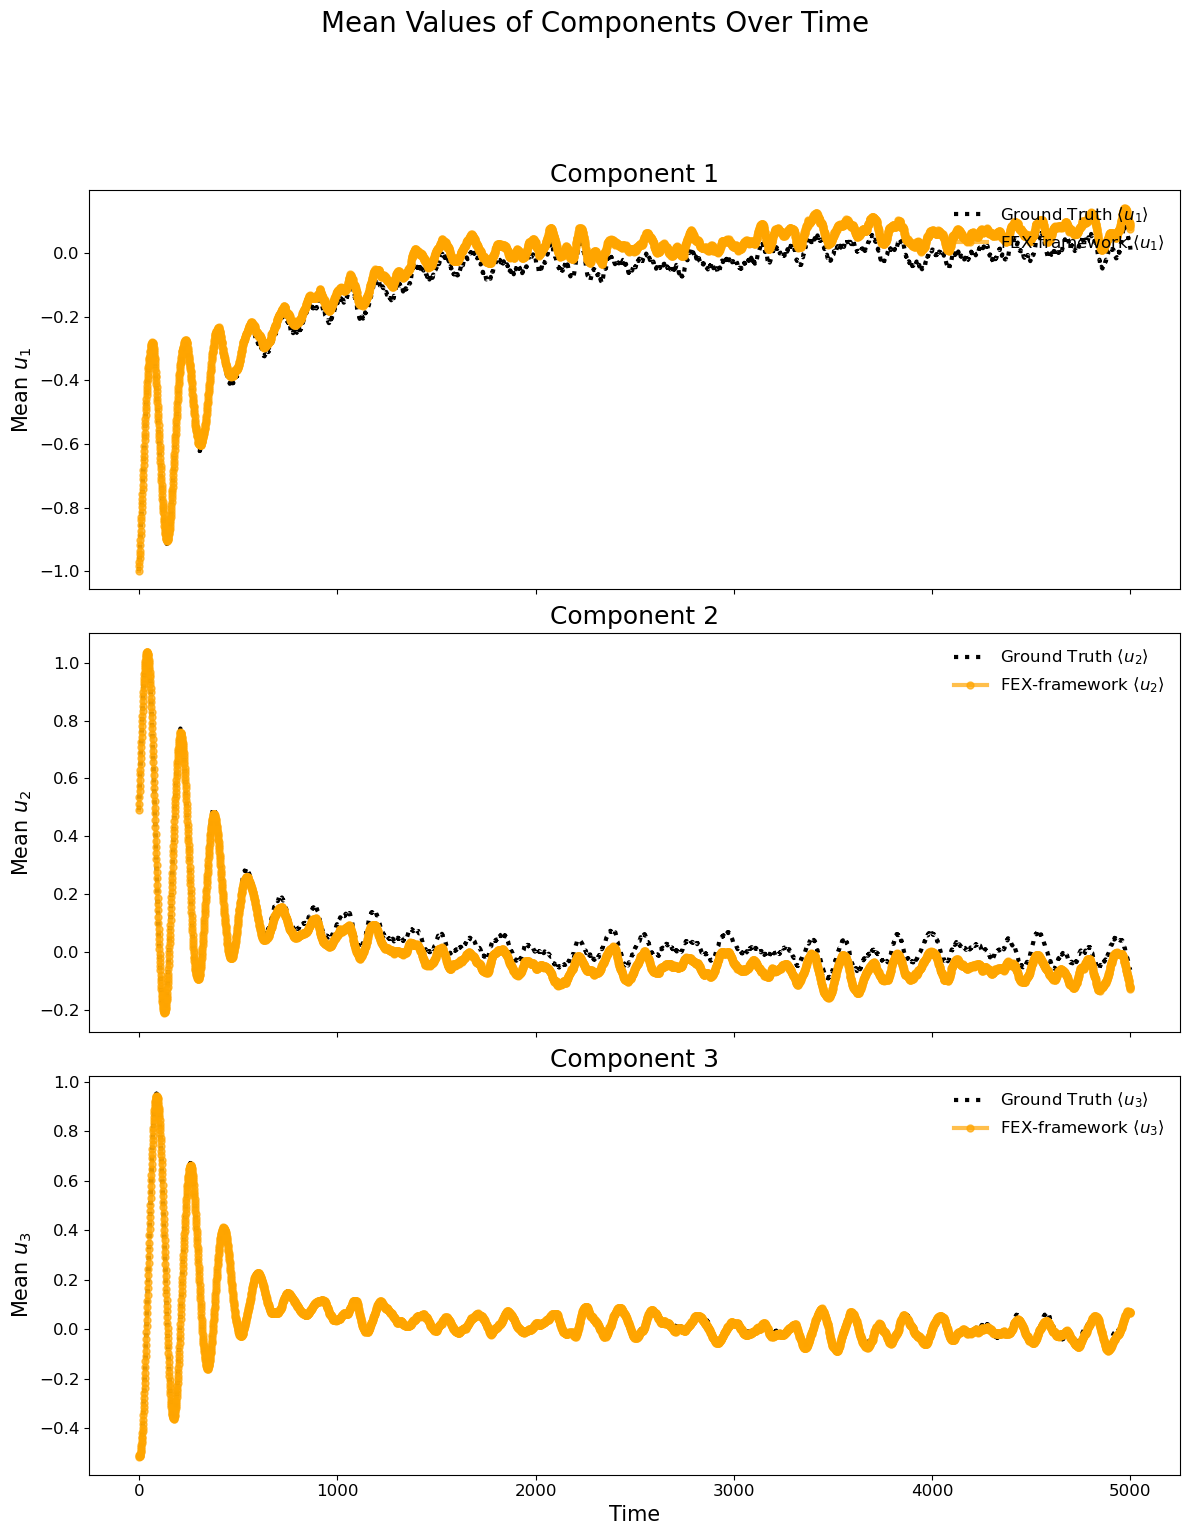

In [4]:
print(mean_state_record.shape)
np.random.seed(0)
Time_record = np.arange(int(TIME_AMOUNT/dt)+1)

# Plot each component separately
component_names = ['u1', 'u2', 'u3']
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# Color & Style Setup - using the requested color scheme
colors = {'Ground-Truth': 'black', 'Prediction': 'orange'}
linestyles = {'Ground-Truth': ':', 'Prediction': '-'}
markers = {'Prediction': 'o'}

for i in range(3):
    # True values
    mask_true = mean_state_record[i] != 0
    axs[i].plot(Time_record[mask_true], mean_state_record[i][mask_true], 
                linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3,
                label=fr'Ground Truth $\langle u_{i+1} \rangle$')
    
    # Predicted values
    mask_pred = mean_state_pred[i] != 0
    axs[i].plot(Time_record[mask_pred], mean_state_pred[i][mask_pred], 
               linestyle=linestyles['Prediction'], color=colors['Prediction'], 
               linewidth=3, marker=markers['Prediction'], markersize=5, alpha=0.7,
               label=fr'FEX-framework $\langle u_{i+1} \rangle$')
    
    axs[i].set_ylabel(fr'Mean $u_{i+1}$', fontsize=15)
    axs[i].set_title(f'Component {i+1}', fontsize=18)
    axs[i].legend(loc='upper right', frameon=False, fontsize=12)
    axs[i].tick_params(axis='both', labelsize=12)

axs[2].set_xlabel('Time', fontsize=15)
plt.tight_layout()
plt.suptitle('Mean Values of Components Over Time', fontsize=20, y=1.02)
plt.subplots_adjust(top=0.9)  # Adjust top to make room for the title
plt.savefig(os.path.join(model_path, 'mean_components_over_time.pdf'), dpi=300, bbox_inches='tight')
plt.show()

(3, 3, 5001)


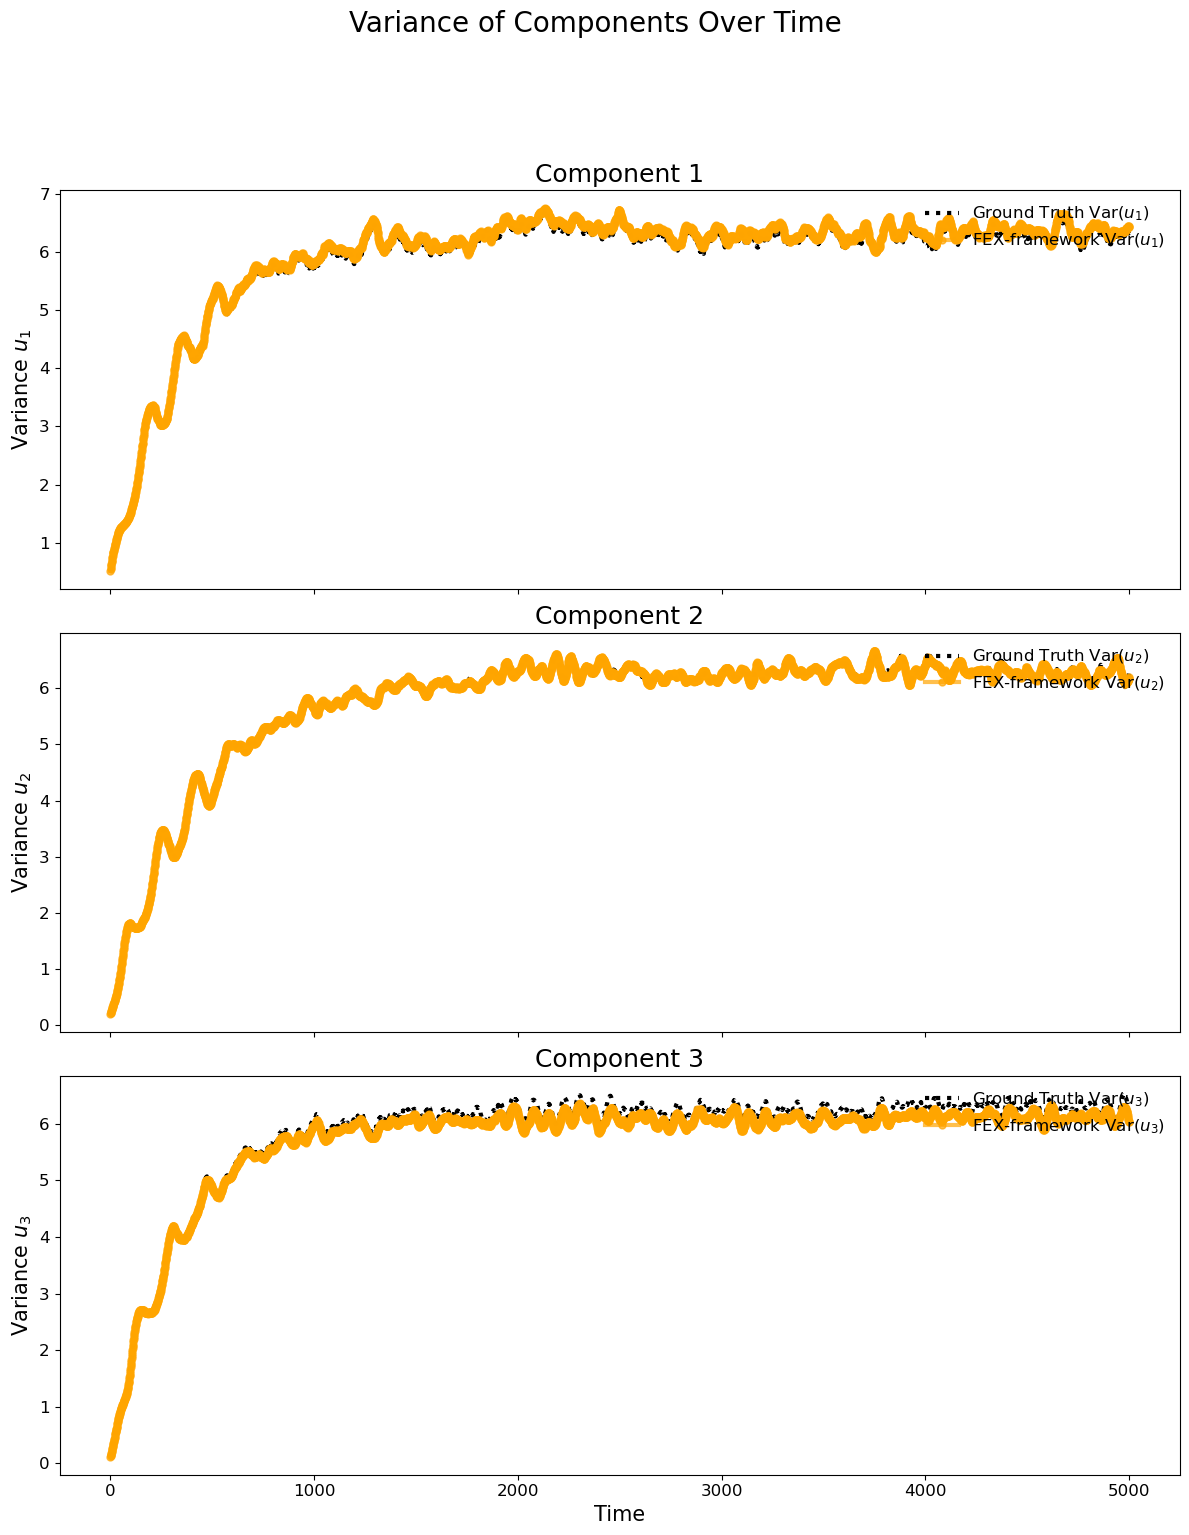

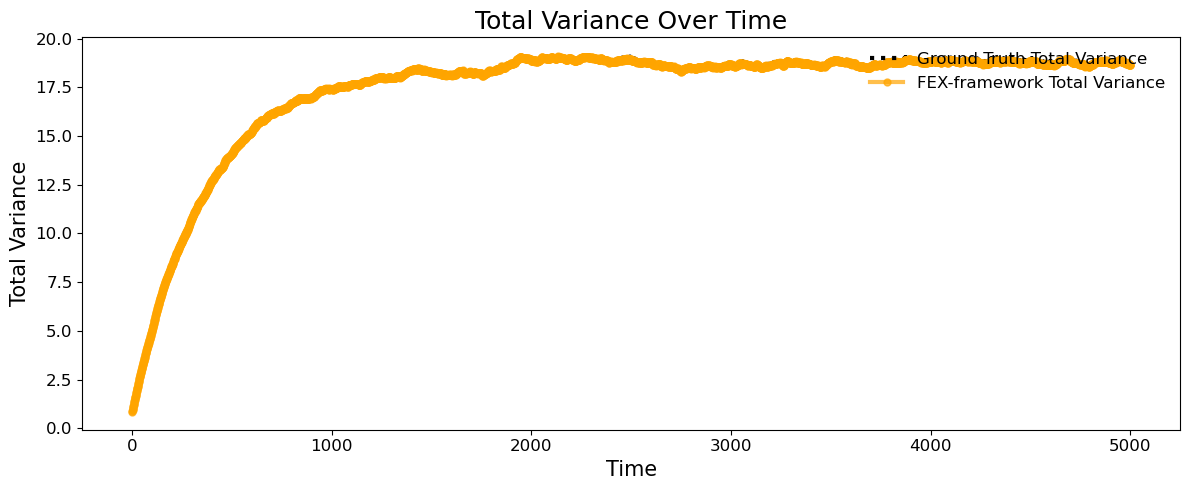

In [5]:
print(cov_state_record.shape)
np.random.seed(0)
Time_record = np.arange(int(TIME_AMOUNT/dt)+1)

# Plot each component's variance separately
component_names = ['u1', 'u2', 'u3']
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# Color & Style Setup - using the requested color scheme
colors = {'Ground-Truth': 'black', 'Prediction': 'orange'}
linestyles = {'Ground-Truth': ':', 'Prediction': '-'}
markers = {'Prediction': 'o'}

for i in range(3):
    # True variance values (diagonal of covariance matrix)
    mask_true = cov_state_record[i, i, :] != 0
    axs[i].plot(Time_record[mask_true], cov_state_record[i, i, mask_true], 
                linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3,
                label=fr'Ground Truth $\mathrm{{Var}}(u_{i+1})$')
    
    # Predicted variance values
    mask_pred = cov_state_pred[i, i, :] != 0
    axs[i].plot(Time_record[mask_pred], cov_state_pred[i, i, mask_pred], 
               linestyle=linestyles['Prediction'], color=colors['Prediction'], 
               linewidth=3, marker=markers['Prediction'], markersize=5, alpha=0.7,
               label=fr'FEX-framework $\mathrm{{Var}}(u_{i+1})$')
    
    axs[i].set_ylabel(fr'Variance $u_{i+1}$', fontsize=15)
    axs[i].set_title(f'Component {i+1}', fontsize=18)
    axs[i].legend(loc='upper right', frameon=False, fontsize=12)
    axs[i].tick_params(axis='both', labelsize=12)

axs[2].set_xlabel('Time', fontsize=15)
plt.tight_layout()
plt.suptitle('Variance of Components Over Time', fontsize=20, y=1.02)
plt.subplots_adjust(top=0.9)  # Adjust top to make room for the title
plt.savefig(os.path.join(model_path, 'variance_components_over_time.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# You can also create plots for the total variance
total_var_true = np.zeros(int(TIME_AMOUNT/dt)+1)
total_var_pred = np.zeros(int(TIME_AMOUNT/dt)+1)

for i in range(3):
    total_var_true += cov_state_record[i, i, :]
    total_var_pred += cov_state_pred[i, i, :]

# Plot the total variance
plt.figure(figsize=(12, 5))
plt.plot(Time_record, total_var_true, linestyle=linestyles['Ground-Truth'], 
         color=colors['Ground-Truth'], linewidth=3, label='Ground Truth Total Variance')
plt.plot(Time_record, total_var_pred, linestyle=linestyles['Prediction'], 
         color=colors['Prediction'], linewidth=3, marker=markers['Prediction'], 
         markersize=5, alpha=0.7, label='FEX-framework Total Variance')
plt.xlabel('Time', fontsize=15)
plt.ylabel('Total Variance', fontsize=15)
plt.title('Total Variance Over Time', fontsize=18)
plt.legend(loc='upper right', frameon=False, fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(model_path, 'total_variance_over_time.pdf'), dpi=300, bbox_inches='tight')
plt.show()

(3, 3, 5001)


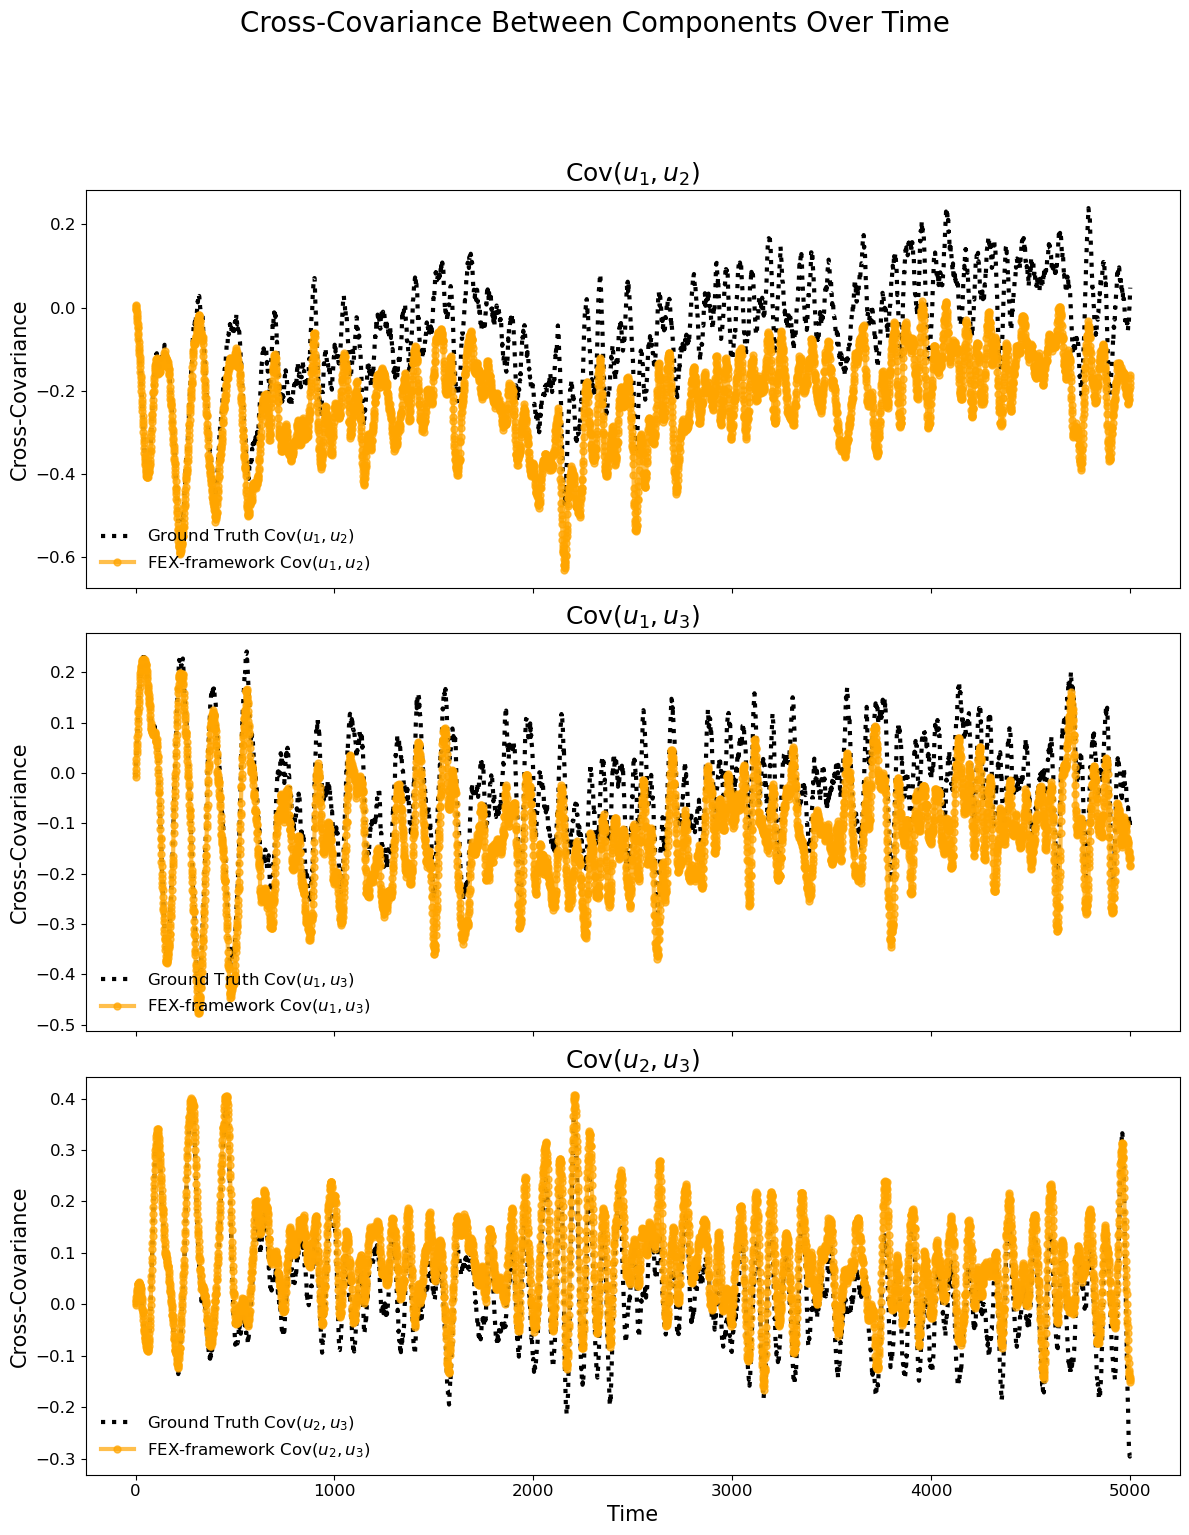

In [6]:
print(cov_state_record.shape)
np.random.seed(0)
Time_record = np.arange(int(TIME_AMOUNT/dt)+1)

# Plot cross-covariances
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
cross_cov_pairs = [(0, 1), (0, 2), (1, 2)]
pair_labels = [r'$\mathrm{Cov}(u_1, u_2)$', r'$\mathrm{Cov}(u_1, u_3)$', r'$\mathrm{Cov}(u_2, u_3)$']

# Color & Style Setup - using the requested color scheme
colors = {'Ground-Truth': 'black', 'Prediction': 'orange'}
linestyles = {'Ground-Truth': ':', 'Prediction': '-'}
markers = {'Prediction': 'o'}

for idx, (i, j) in enumerate(cross_cov_pairs):
    # True cross-covariance values
    mask_true = cov_state_record[i, j, :] != 0
    axs[idx].plot(Time_record[mask_true], cov_state_record[i, j, mask_true], 
                 linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3,
                 label=f'Ground Truth {pair_labels[idx]}')
    
    # Predicted cross-covariance values
    mask_pred = cov_state_pred[i, j, :] != 0
    axs[idx].plot(Time_record[mask_pred], cov_state_pred[i, j, mask_pred], 
                 linestyle=linestyles['Prediction'], color=colors['Prediction'], 
                 linewidth=3, marker=markers['Prediction'], markersize=5, alpha=0.7,
                 label=f'FEX-framework {pair_labels[idx]}')
    
    axs[idx].set_ylabel(f'Cross-Covariance', fontsize=15)
    axs[idx].set_title(f'{pair_labels[idx]}', fontsize=18)
    axs[idx].legend(loc='lower left', frameon=False, fontsize=12)
    axs[idx].tick_params(axis='both', labelsize=12)

axs[2].set_xlabel('Time', fontsize=15)
plt.tight_layout()
plt.suptitle('Cross-Covariance Between Components Over Time', fontsize=20, y=1.02)
plt.subplots_adjust(top=0.9)  # Adjust top to make room for the title
plt.savefig(os.path.join(model_path, 'cross_covariance_over_time.pdf'), dpi=300, bbox_inches='tight')
plt.show()

(3, 3, 3, 5001)


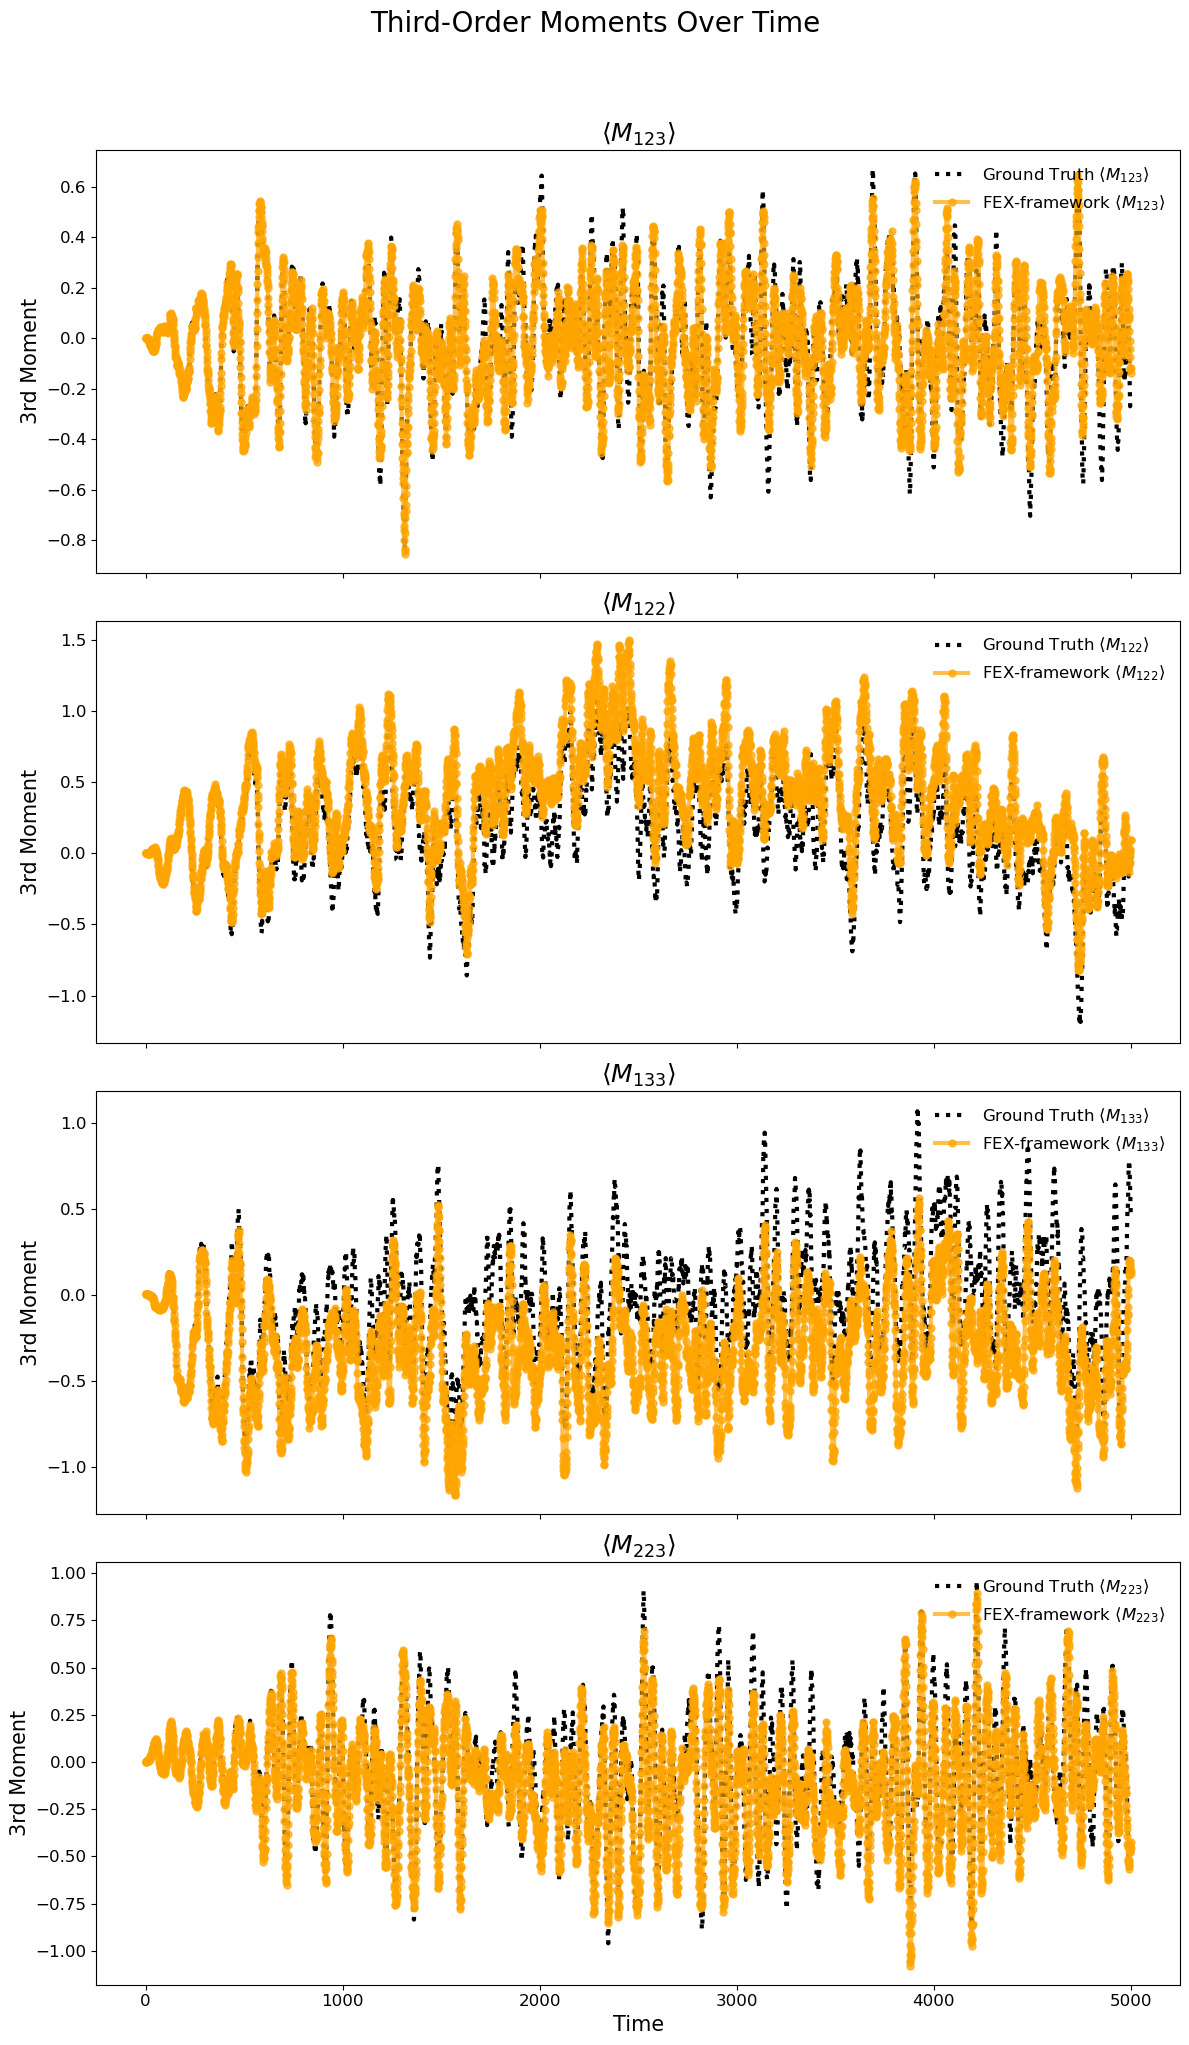

In [7]:
print(moment3_state_record.shape)
np.random.seed(0)
Time_record = np.arange(int(TIME_AMOUNT/dt)+1)

# Plot 3rd-order moments
fig, axs = plt.subplots(4, 1, figsize=(12, 20), sharex=True)
moment_indices = [(0, 1, 2), (0, 1, 1), (0, 2, 2), (1, 1, 2)]
moment_labels = [r'$\langle M_{123} \rangle$', r'$\langle M_{122} \rangle$', 
                r'$\langle M_{133} \rangle$', r'$\langle M_{223} \rangle$']

# Color & Style Setup - using the requested color scheme
colors = {'Ground-Truth': 'black', 'Prediction': 'orange'}
linestyles = {'Ground-Truth': ':', 'Prediction': '-'}
markers = {'Prediction': 'o'}

for idx, (i, j, k) in enumerate(moment_indices):
    # True 3rd-order moment values
    mask_true = moment3_state_record[i, j, k, :] != 0
    axs[idx].plot(Time_record[mask_true], moment3_state_record[i, j, k, mask_true], 
                 linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3,
                 label=f'Ground Truth {moment_labels[idx]}')
    
    # Predicted 3rd-order moment values
    mask_pred = moment3_state_pred[i, j, k, :] != 0
    axs[idx].plot(Time_record[mask_pred], moment3_state_pred[i, j, k, mask_pred], 
                 linestyle=linestyles['Prediction'], color=colors['Prediction'], 
                 linewidth=3, marker=markers['Prediction'], markersize=5, alpha=0.7,
                 label=f'FEX-framework {moment_labels[idx]}')
    
    axs[idx].set_ylabel(f'3rd Moment', fontsize=15)
    axs[idx].set_title(f'{moment_labels[idx]}', fontsize=18)
    axs[idx].legend(loc='upper right', frameon=False, fontsize=12)
    axs[idx].tick_params(axis='both', labelsize=12)

axs[3].set_xlabel('Time', fontsize=15)
plt.tight_layout()
plt.suptitle('Third-Order Moments Over Time', fontsize=20, y=1.02)
plt.subplots_adjust(top=0.95)  # Adjust top to make room for the title
plt.savefig(os.path.join(model_path, 'third_order_moments_over_time.pdf'), dpi=300, bbox_inches='tight')
plt.show()

[[-3.16333077  1.16333077]
 [-0.84164079  1.84164079]
 [-1.53923048  0.53923048]]


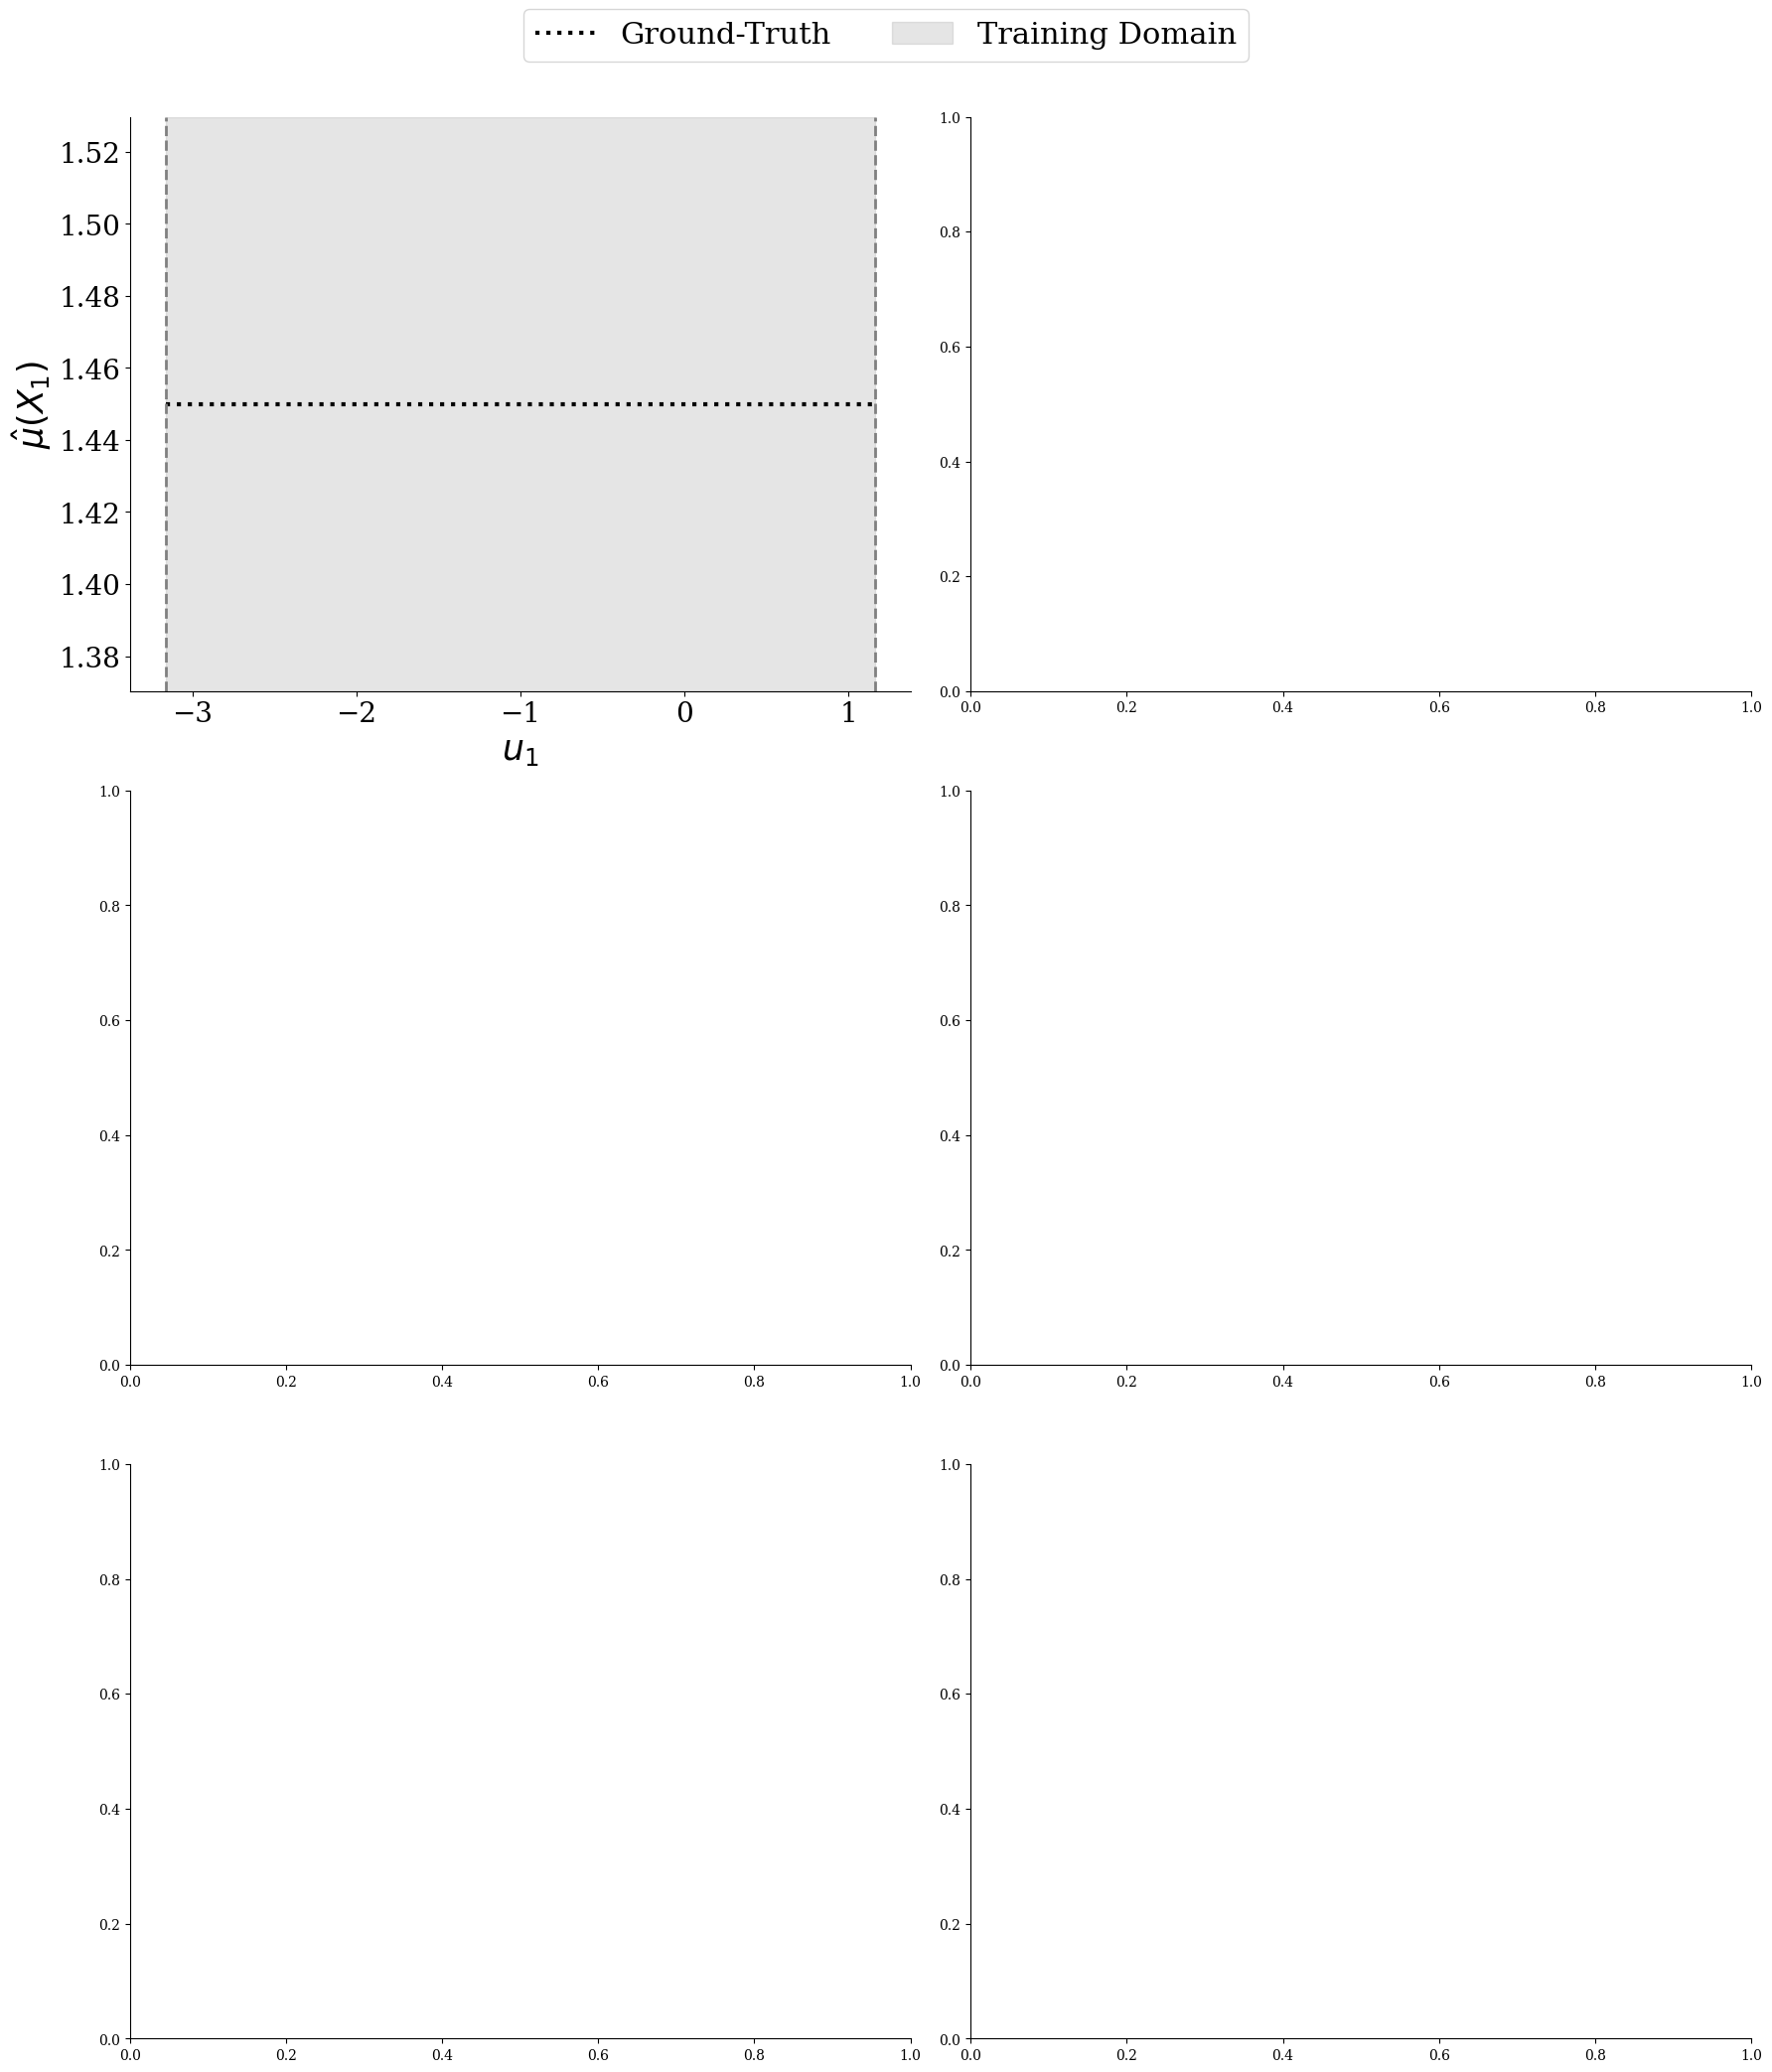

In [19]:
NPATH = 100000
NSample = 500
np.random.seed(0)
m0, var0 = MC_triad_initial_value()
DOMAIN = np.zeros((3,2))
for domain_idx in range(3):
    DOMAIN[domain_idx,0] = m0[domain_idx] - 3*np.sqrt(var0[domain_idx]) # 3 here for 99.7% confidence interval
    DOMAIN[domain_idx,1] = m0[domain_idx] + 3*np.sqrt(var0[domain_idx])

print(DOMAIN)

params = params_init('equipart')
x0_grid_all = np.array([np.linspace(DOMAIN[k, 0], DOMAIN[k, 1], NSample) for k in range(3)])


drift_pred = np.zeros((NSample,3))
sigma_pred = np.zeros((NSample,3))

drift_true = np.zeros((NSample,3))
sigma_true = np.tile(np.diag(params['SS']), (NSample, 1)) 


L = params['L']
G = params['G']
B = params['B']

for idx in range(NSample):
    true_init = x0_grid_all[:,idx]

    current_state = np.ones((NPATH, 3)) * m0
    next_state_deterministic = current_state + params['Dt'] * ((L @ current_state.T).T - current_state @ G + Buu(B, current_state, current_state) + np.ones((NPATH, 1)) * params['tmM'][idx - 1, :])
    SS = params['SS'] + params['tmS'][idx - 1] ** 2 * (params['SSt'] - params['SS'])
    Winc = np.random.randn(NPATH, 3)  # shape (MC, 3)
    next_state = next_state_deterministic + np.sqrt(params['Dt']) * (Winc @ SS)
    drift_true[idx,:] = np.mean((next_state_deterministic - current_state)/params['Dt'],axis=0)


    # x_pred_new_FEX_np = x_pred_new.to('cpu').detach().numpy()    
    # prediction_FEX = TWO_STAGE_Model(dt,x_pred_new,FEX_model,FN_func_params,device)
    # prediction_FEX_np = prediction_FEX.to('cpu').detach().numpy()

    # prediction_FEX = prediction_FEX_np + x_pred_new_FEX_np
    
#     another_using_true_init = np.array([true_init,true_init]).astype(np.float32)
#     bx_pred_FEX = ((prediction_FEX-another_using_true_init)/sde_dt)
#     # print(prediction)
#     # print(bx_pred)
#     drift_pred_1_FEX[jj] = np.mean(bx_pred_FEX[:,0])
#     # print(drift_pred_1)
#     drift_pred_2_FEX[jj] = np.mean(bx_pred_FEX[:,1])
#     # print(drift_pred_2)
#     bb_mean_FEX = np.array([drift_pred_1_FEX[jj],drift_pred_2_FEX[jj]]).astype(np.float32)
#     sigmax = ((prediction_FEX-another_using_true_init-bb_mean_FEX*sde_dt))
#     sigmax_pred_1_FEX[jj] = np.std(sigmax[:,0])/np.sqrt(sde_dt)
#     sigmax_pred_2_FEX[jj] = np.std(sigmax[:,1])/np.sqrt(sde_dt)
    

#     prediction = FN( (torch.hstack((x_pred_new,torch.randn(Npath,x_dim).to(device,dtype= torch.float32)))-xTrain_mean)/xTrain_std  ) * yTrain_std + yTrain_mean 
#     prediction_np = prediction.to('cpu').detach().numpy()
#     x_pred_new_np = x_pred_new.to('cpu').detach().numpy()
#     prediction_np = prediction_np / diff_scale
#     prediction = prediction_np + x_pred_new_np 
#     another_using_true_init = np.array([true_init,true_init]).astype(np.float32)
#     bx_pred = ((prediction-another_using_true_init)/sde_dt)
#     # print(prediction)
#     # print(bx_pred)
#     drift_pred_1_zhang[jj] = np.mean(bx_pred[:,0])
#     # print(drift_pred_1)
#     drift_pred_2_zhang[jj] = np.mean(bx_pred[:,1])
#     # print(drift_pred_2)
#     bb_mean = np.array([drift_pred_1_zhang[jj],drift_pred_2_zhang[jj]]).astype(np.float32)
#     sigmax = ((prediction-another_using_true_init-bb_mean*sde_dt))
#     sigmax_pred_1_zhang[jj] = np.std(sigmax[:,0])/np.sqrt(sde_dt)
#     sigmax_pred_2_zhang[jj] = np.std(sigmax[:,1])/np.sqrt(sde_dt)


fig,axs = plt.subplots(3,2,figsize=(18,20))
# # **Color & Style Setup**
colors = {'FEX-framework': 'orange', 'Ground-Truth': 'black'}
linestyles = {'FEX-framework': '--', 'Ground-Truth': ':'}
markers = {'FEX-framework': 'o',}


#axs[0,0].plot(x0_grid,np.squeeze(drift_pred),label='FEX-DM', linestyle=linestyles['FEX-framework'], color=colors['FEX-framework'], linewidth=3, marker=markers['FEX-framework'], markersize=5)
axs[0,0].plot(x0_grid_all[0],(drift_true[:,0]),label = 'Ground-Truth', linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3)
axs[0,0].axvspan(DOMAIN[0,0], DOMAIN[0,1], color='gray', alpha=0.2, label="Training Domain")
axs[0,0].axvline(DOMAIN[0,0], color='gray', linestyle='--', linewidth=2)
axs[0,0].axvline(DOMAIN[0,1], color='gray', linestyle='--', linewidth=2)
axs[0,0].set_xlabel(r'${u_1}$', fontsize=25)
axs[0,0].set_ylabel(r'$\hat{\mu}(X_1)$',fontsize =25)
# # axs[0,0].legend(fontsize = 20)
axs[0,0].tick_params(axis='both',labelsize=20)


# axs[0,1].plot(x0_grid,sigmax_pred_1_FEX, label='FEX-TF-DM', linestyle=linestyles['FEX+Zhang'], color=colors['FEX+Zhang'], linewidth=3, marker=markers['FEX+Zhang'], markersize=5)
# axs[0,1].plot(x0_grid,sigmax_pred_1_zhang,label='TF-CDM',linestyle=linestyles['Zhang'], color=colors['Zhang'], linewidth=3, marker=markers['Zhang'], markersize=2)
# axs[0,1].plot(x0_grid,sigmax_true,label = 'Ground-Truth', linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3)
# axs[0,1].axvspan(-1, 1, color='gray', alpha=0.2, label="Training Domain")
# axs[0,1].axvline(-1, color='gray', linestyle='--', linewidth=2)
# axs[0,1].axvline(1, color='gray', linestyle='--', linewidth=2)
# axs[0,1].set_xlabel('$X_1$',fontsize=25)
# axs[0,1].set_ylabel(r'$\hat{\sigma}(X_1)$',fontsize=25)
# # axs[0,1].legend(fontsize = 20)
# axs[0,1].tick_params(axis='both',labelsize=20)
# axs[0,1].set_ylim([1, 1.6])


# axs[1,0].plot(x0_grid,drift_pred_2_FEX,label='FEX-TF-DM', linestyle=linestyles['FEX+Zhang'], color=colors['FEX+Zhang'], linewidth=3, marker=markers['FEX+Zhang'], markersize=5)
# axs[1,0].plot(x0_grid,drift_pred_2_zhang,label='TF-CDM',linestyle=linestyles['Zhang'], color=colors['Zhang'], linewidth=3, marker=markers['Zhang'], markersize=2)
# axs[1,0].plot(x0_grid,drift_true_2,label = 'Ground-Truth', linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3)
# axs[1,0].axvspan(-1.5, 1.5, color='gray', alpha=0.2, label="Training Domain")
# axs[1,0].axvline(-1.5, color='gray', linestyle='--', linewidth=2)
# axs[1,0].axvline(1.5, color='gray', linestyle='--', linewidth=2)
# axs[1,0].set_xlabel('$X_2$',fontsize=25)
# axs[1,0].set_ylabel(r'$\hat{\mu}(X_2)$',fontsize =25)
# # axs[1,0].legend(fontsize = 20)
# axs[1,0].tick_params(axis='both',labelsize=20)


# axs[1,1].plot(x0_grid,sigmax_pred_2_FEX,label='FEX-TF-DM', linestyle=linestyles['FEX+Zhang'], color=colors['FEX+Zhang'], linewidth=3, marker=markers['FEX+Zhang'], markersize=5)
# axs[1,1].plot(x0_grid,sigmax_pred_2_zhang,label='TF-CDM',linestyle=linestyles['Zhang'], color=colors['Zhang'], linewidth=3, marker=markers['Zhang'], markersize=2)
# axs[1,1].plot(x0_grid,sigmax_true,label = 'Ground-Truth', linestyle=linestyles['Ground-Truth'], color=colors['Ground-Truth'], linewidth=3)
# axs[1,1].axvspan(-1, 1, color='gray', alpha=0.2, label="Training Domain")
# axs[1,1].axvline(-1, color='gray', linestyle='--', linewidth=2)
# axs[1,1].axvline(1, color='gray', linestyle='--', linewidth=2)
# axs[1,1].set_xlabel('$X_2$',fontsize=25)
# axs[1,1].set_ylabel('$\hat{\sigma}(X_2)$',fontsize=25)
# # axs[1,1].legend(fontsize = 20)
# axs[1,1].tick_params(axis='both',labelsize=20)
# axs[1,1].set_ylim([1, 1.6])
plt.tight_layout()
handles, labels = axs[0,0].get_legend_handles_labels()  # Get legend from first plot
fig.legend(handles, labels, loc='upper center', fontsize=22, frameon=True, ncol=4, bbox_to_anchor=(0.5, 1.05))
# plt.savefig(os.path.join(save_dir,'drift_diffusion_term.pdf'), dpi=300, bbox_inches='tight')
plt.show()